In [1]:
# Compare RBP gene expression with PSI.
# The process is as follows:
# 1. Shortlist the RBP gene expression to those that are "possible predicted" based on co-pull down database.
# 2. Shortlist to genes that have tau >0.5, and dynamic range > 2, because we assume that these RBPs must have some tissue specificity.
# 3. Shortlist to sequences that are singificantly different in at least 2 cell lines based on RMATS output stats, and also those that have PSI at least 4-fold higher or lower in one cell line compared to the others.
# 4. For each sequence, calculate the correlation between gene expression and PSI for each gene. Shortlist to sequences that have correlation > 0.5.
# 5. For each RBP, count how many sequences have correlation > 0.5. Shortlist to top 20 RBPs with the highest number of sequence counts. 

library(tidyverse)
library(vroom)
library(data.table)
library(Biostrings)
library(ggpointdensity)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}
# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/figure_outputs"
dir.create(output_filepath, showWarnings = FALSE)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:data.table’:

    first, second


The following objects are masked from ‘package:lubridate’:

    second, second<-


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘package:tidyr’:

    expand


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: ‘IRanges’


The following object is masked from ‘package:data.table’:

    shift


The following object is masked from ‘package:lubridate’:

    %within%


The following objects are masked from ‘package:dplyr’:

    collapse, desc, slice


The following object is masked from ‘package:purrr’:

    reduce


Loading required package: XVector


Attaching package: ‘XVector’


The following object is masked from ‘package:purrr’:

    compact


Loadin

In [2]:
# This is the Broad gex.
all_gex <- fread("/mnt/dawnccle2/for_anisha/CCLE_expression.csv", sep = ",")
all_gex <- all_gex %>% 
  rename_with(~str_extract(., "^[^\\s]+")) %>% 
  # Rename V1 to DepMap_ID.
  dplyr::rename(DepMap_ID = "V1") 
# Sanger GEX
# all_gex <- fread("C:/Users/dawnxi/Dropbox (Harvard University)/02Splicing/latest/sanger_CCLE_gex_with_Broad_ID.csv")

predicted_RBP_Gerstberger <- fread("/mnt/dawnccle2/melange/data/RBP_possible_Gerstberger_NatRev2014.csv")
RBP_list1 <- predicted_RBP_Gerstberger %>% pull(`gene name`)
predicted_RBP_Hentze <- fread("/mnt/dawnccle2/melange/data/Hentze_2018_RBPs.csv")
RBP_list2 <- predicted_RBP_Hentze %>% pull(UNIQUE)
all_available_RBP <- intersect(colnames(all_gex), c(RBP_list1, RBP_list2))

# Filter to only the predicted RBPs
all_gex_RBP <- all_gex %>% select(DepMap_ID, all_of(all_available_RBP))

# Read in PSI table.
all_sample_reps <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_chimeric_rate_considering_included/WT_all_samples_PSI_count_table_filtered.csv")
all_sample_reps <- all_sample_reps %>% 
  # Mutate condition Kelly to KELLY
  mutate(condition = ifelse(condition == "Kelly", "KELLY", condition)) %>%
  group_by(condition, index_offset) %>% 
  summarise(PSI = mean(PSI, na.rm = T), n = n()) %>%
  filter(n >= 2) %>%
  select(-n) %>% 
  ungroup()

all_samples_wide <- all_sample_reps %>%
  pivot_wider(names_from = condition, values_from = PSI, values_fill = NA)

all_samples_mat <- as.matrix(all_samples_wide[, -1])
rownames(all_samples_mat) <- all_samples_wide$index_offset

cellline_metadata <- fread("/mnt/dawnccle2/for_anisha/cellline_data_full_metadata.csv") %>% 
  select(DepMap_ID, StrippedName) %>% distinct()
# Rename V1 in gex based on cellline_metadata
gex_formatted <- all_gex_RBP %>% 
  left_join(cellline_metadata, by = "DepMap_ID") %>% 
  select(-DepMap_ID) %>% 
  dplyr::rename(condition = "StrippedName") %>%
  filter(condition %in% c(colnames(all_samples_mat)))

# Get common cell lines in gex and all_samples_mat
common_cell_lines <- intersect(colnames(all_samples_mat), gex_formatted$condition)
#convert to matrix no condition column
gex_mat <- as.matrix(gex_formatted %>% select(-condition))
rownames(gex_mat) <- gex_formatted$condition
# Order matrices based on the common names
gex_mat_aligned <- gex_mat[common_cell_lines,]
# Order the all_samples_mat based on the names
all_samples_mat_aligned <- all_samples_mat[, common_cell_lines]
# subset to only rows that has <20% NA.
all_samples_mat_aligned <- all_samples_mat_aligned[rowMeans(is.na(all_samples_mat_aligned)) <= 0.2, ]


# Write the aligned matrix to output csv. 
# Create dir U:/processed_data/reprocess_250221/rbp_gex_outputs
# dir.create("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs", showWarnings = FALSE)
# write.csv(t(all_samples_mat_aligned), "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/df_all_samples_mat_aligned.csv")
# write.csv(gex_mat_aligned, "U:/processed_data/reprocess_250221/rbp_gex_outputs/df_gex_mat_aligned.csv")



`summarise()` has grouped output by 'condition'. You can override using the
`.groups` argument.


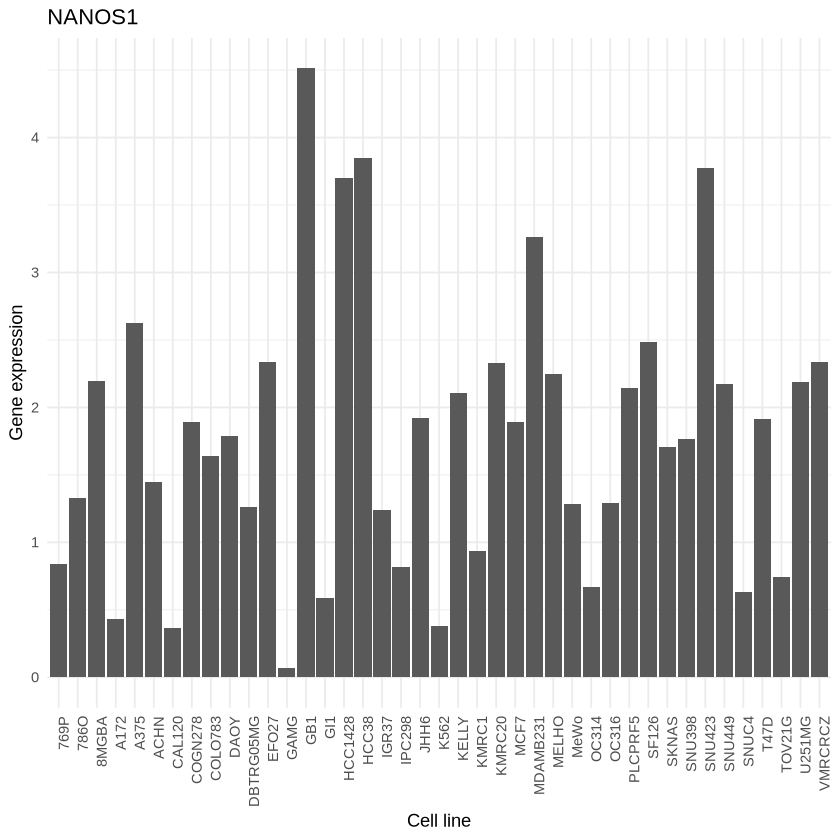

In [3]:
# Plot gene expression for one gene
gene_name <- "NANOS1"
gex_shortlist <- data.frame(gex = gex_mat_aligned[, gene_name], cell_line = rownames(gex_mat_aligned))
# Plot the gene expression for RBM39 as barplot
ggplot(gex_shortlist, aes(x = cell_line, y = gex)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(x = "Cell line", y = "Gene expression") +
  ggtitle(gene_name)



[1] "ENSG00000003756.17;RBM5;chr3-50108231-50108304-50108069-50108147-50109602-50109688__0:0:0"
[1] 1


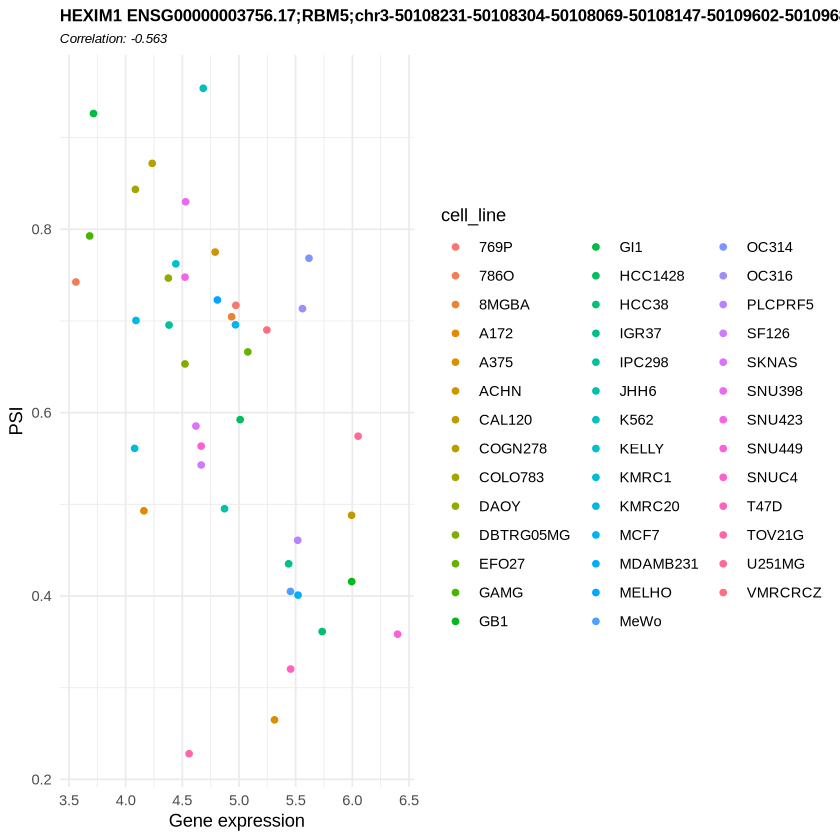

In [4]:
##########################################
###### Calculate correlation matrix ######
##########################################
# Calculate correlation for every seq and gene pair.
# correlation_matrix <- cor(t(all_samples_mat_aligned), gex_mat_aligned, use = "pairwise.complete.obs")

# Plot correlation for one gene
gene_name <- "HEXIM1"
seq_base <- "ENSG00000003756.17;RBM5;chr3-50108231-50108304-50108069-50108147-50109602-50109688"
matching_seqs <- grep(seq_base, rownames(all_samples_mat_aligned), value = TRUE)
# Print matching seqs and how many. 
print(matching_seqs)
print(length(matching_seqs))
seq_name <- matching_seqs[1]
gex_RBFOX2 <- gex_mat_aligned[, gene_name]
psi_RBFOX2 <- all_samples_mat_aligned[seq_name, ]
corr_val <- cor(gex_RBFOX2, psi_RBFOX2, use = "pairwise.complete.obs", method = "pearson")
plot_df <- data.frame(gex_RBFOX2, psi_RBFOX2, cell_line = rownames(gex_mat_aligned))
ggplot(plot_df, aes(x = gex_RBFOX2, y = psi_RBFOX2, color = cell_line)) +
  geom_point() + 
  theme_minimal() +
  labs(x = "Gene expression", y = "PSI") + 
  ggtitle(paste(gene_name, seq_name)) + 
  # Add subtitle with the gene name and sequence name
  theme(plot.title = element_text(size = 10, face = "bold"),
        plot.subtitle = element_text(size = 8, face = "italic")) + 
  # Add correlation as subtitle text
  labs(subtitle = paste("Correlation:", round(corr_val, 3)))



In [5]:
###############################
###### Calculate tau ######
###############################
# Calculate tau for the gex values. 
tau_values <- apply(gex_mat_aligned, 2, calculate_tau)
# calculate dynamic range.
dynamic_range <- apply(gex_mat_aligned, 2, function(x) max(x, na.rm =T) - min(x, na.rm = T))

# Calculate variance. Remove NA values.
variance <- apply(gex_mat_aligned, 2, var, na.rm = T)
# convert the values to a df.
tau_df <- data.frame(gene = names(tau_values), tau = tau_values, dynamic_range = dynamic_range, variance = variance)
# Shortlist to tau >0.5 and dynamic_range > 2 in the gex_mat_aligned.
# shortlist_genes <- tau_df %>% filter(tau > 0.5 & dynamic_range > 2) %>% pull(gene)
# Shortlist to top 20% of genes with highest variance. 
shortlist_genes <- tau_df %>% arrange(desc(variance)) %>% head(nrow(tau_df) * 0.2) %>% pull(gene)

# Subset the gex_mat_aligned to the shortlist_genes.
gex_mat_aligned_shortlist <- gex_mat_aligned[, c(shortlist_genes)]


In [6]:
##############################################################
###### Get signfiicantly differentially expressed genes ######
##############################################################
combined_psi <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/pairadise_indiv_PSI/WT_PSI_combined_output_indiv.tsv")
calculate_ratio <- function(I, S) {
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  ratio <- I_values / (I_values + S_values)
  return(paste(round(ratio,3), collapse = ","))
}


calculate_average <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  average <- mean(PSI_values)
  return(round(average, 3))
}


get_max_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  max_PSI <- max(PSI_values)
  return(round(max_PSI, 3))
}


get_min_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  min_PSI <- min(PSI_values)
  return(round(min_PSI, 3))
}


calculate_average_count_sum <- function(I, S){
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  total_sum <- I_values + S_values
  average_count_sum <- mean(total_sum)
  return(round(average_count_sum, 0))
}

# Apply the function to the data frame
combined_psi <- combined_psi %>%
  mutate(
    PSI1 = mapply(calculate_ratio, I1, S1),
    PSI2 = mapply(calculate_ratio, I2, S2)
  ) %>% 
  mutate(
    PSI1_average = mapply(calculate_average, PSI1),
    PSI2_average = mapply(calculate_average, PSI2)
  ) %>%
  mutate(PSI_diff = PSI1_average - PSI2_average) %>% 
  mutate(
    count_sum_average1 = mapply(calculate_average_count_sum, I1, S1),
    count_sum_average2 = mapply(calculate_average_count_sum, I2, S2)
  ) %>% mutate(PSI_ratio = PSI1_average / PSI2_average) %>% 
  mutate(PSI_reverse_ratio = (1-PSI1_average)/(1-PSI2_average)) %>% 
  mutate(max_PSI1 = mapply(get_max_PSI, PSI1), max_PSI2 = mapply(get_max_PSI, PSI2)) %>% 
  mutate(min_PSI1 = mapply(get_min_PSI, PSI1), min_PSI2 = mapply(get_min_PSI, PSI2))

combined_psi_filtered <- combined_psi %>% 
  filter(count_sum_average1 > 30) %>% 
  filter(count_sum_average2 > 30) %>% 
  mutate(log2_PSI_ratio = log2(PSI_ratio), log2_PSI_reverse_ratio = log2(PSI_reverse_ratio))

top_seq <- combined_psi_filtered %>% filter(abs(log2_PSI_ratio) > 2 | abs(log2_PSI_reverse_ratio) > 2)  # filter(abs(PSI_diff) > 0.4)
num_obs_per_seq <- top_seq %>% group_by(ExonID) %>% summarise(num_obs = n())
top_seq <- top_seq %>% left_join(num_obs_per_seq, by = "ExonID") %>% filter(num_obs > 1)

In [7]:
# Get the sequences with the top 20% variance.
# calculate variance for each sequence.
psi_variance <- apply(all_samples_mat_aligned, 1, var, na.rm = T)
psi_tau <- apply(all_samples_mat_aligned, 1, calculate_tau)
psi_reverse_tau <- apply(1-all_samples_mat_aligned, 1, calculate_tau)
psi_dynamic_range <- apply(all_samples_mat_aligned, 1, function(x) max(x, na.rm = T) - min(x, na.rm = T))
psi_upsilon <- apply(all_samples_mat_aligned, 1, calculate_upsilon)
psi_reverse_upsilon <- apply(1-all_samples_mat_aligned, 1, calculate_upsilon)
psi_stats_df <- data.frame(seq = rownames(all_samples_mat_aligned), variance = psi_variance, tau = psi_tau, dynamic_range = psi_dynamic_range, upsilon = psi_upsilon, reverse_upsilon = psi_reverse_upsilon)

# Shortlist to the top 20% of sequences with highest variance.
shortlist_seqs <- psi_stats_df %>% arrange(desc(variance)) %>% head(nrow(psi_stats_df) * 0.2) %>% pull(seq)

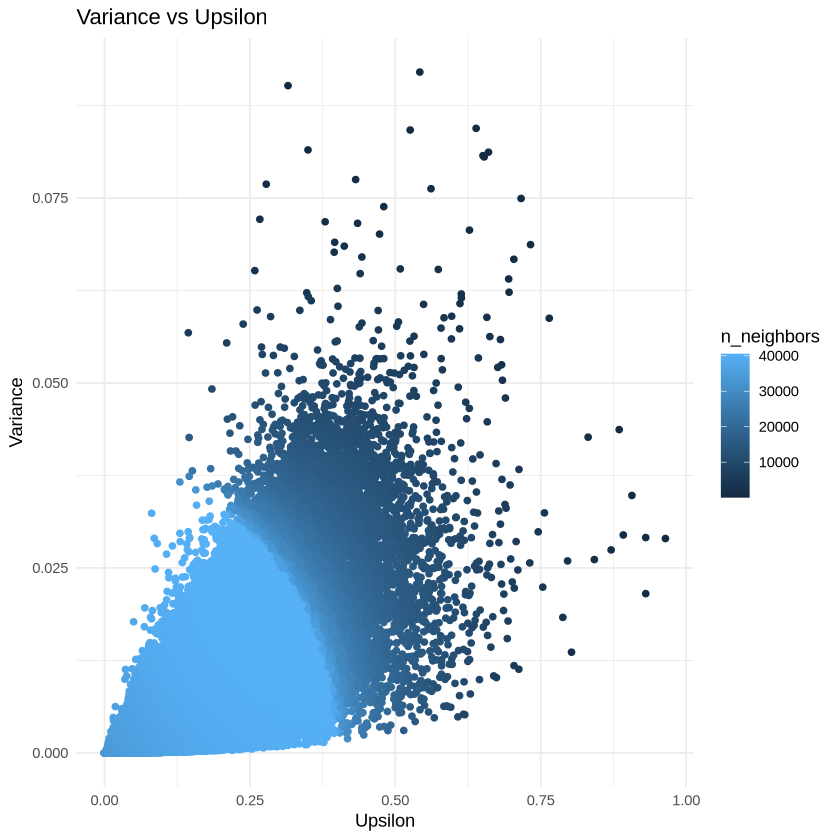

In [8]:
# Plot scatter of variance vs upsilon.
ggplot(psi_stats_df, aes(x = upsilon, y = variance)) +
  geom_pointdensity() +
  theme_minimal() +
  labs(x = "Upsilon", y = "Variance") + 
  ggtitle("Variance vs Upsilon")


In [9]:
# # Extract gene and exon IDs
# # exon_list <- unique(top_seq$ExonID) # Len is 1966
# # gene_list <- colnames(gex_mat_aligned_shortlist) # length is 117
# exon_list <- shortlist_seqs
# gene_list <- shortlist_genes

# # Function to calculate correlations for a given exon
# calculate_correlation_for_exon <- function(seq) {
#   # Check that the sequence is in the rownames of all_samples_mat_aligned
#   if (!seq %in% rownames(all_samples_mat_aligned)) {
#     return(tibble(Gene = NA, Exon = seq, Correlation = NA, p.val = NA))
#   }
#   # Get PSI values for the given exon
#   psi_values <- all_samples_mat_aligned[seq, ]
  
#   # Calculate correlations with all genes
#   correlations <- map_dfr(gene_list, function(gene) {
#     gex_values <- gex_mat_aligned_shortlist[, gene]
#     # If the range of values is too small, return NA.
#     if (max(gex_values, na.rm = T) - min(gex_values, na.rm = T) < 1) {
#       return(tibble(Gene = gene, Exon = seq, Correlation = NA, p.val = NA))
#     }
#     corr_test <- cor.test(gex_values, psi_values, use = "pairwise.complete.obs", method = "pearson")
#     corr_val <- corr_test$estimate
#     p_value <- corr_test$p.value
#     tibble(Gene = gene, Exon = seq, Correlation = corr_val, p.val = p_value)
#   })
  
#   return(correlations)
# }

# # Calculate correlations for all exons and combine results
# correlation_df <- map_dfr(exon_list, calculate_correlation_for_exon)
# # Adjust p-values by FDR
# # TBH after adjusting there's nothing left...
# correlation_df$p.val_adj <- p.adjust(correlation_df$p.val, method = "fdr")
# correlation_df_sig <- correlation_df %>% filter(abs(Correlation) > 0.5)


# # get top 20 absolute values
# # top_correlations <- correlation_df %>% arrange(desc(abs(Correlation))) %>% head(20)
# high_correlations <- correlation_df %>% 
#   filter(abs(Correlation) > 0.5) %>% 
#   # filter(p.val_adj < 0.05) %>%
#   group_by(Gene) %>% 
#   summarise(num_high_correlations = n()) %>% 
#   arrange(desc(num_high_correlations)) 
# # write_csv(high_correlations, "~/Dropbox (Harvard University)/02Splicing/test_psi_high_corr_rmats_sig_seq_first/high_corr_all_sequences.csv")


# # Get the high correlations for the top 20.
# top_correlations <- correlation_df %>% 
#   # filter(p.val_adj < 0.05)
#   filter(Gene %in% high_correlations$Gene) %>% 
#   filter(abs(Correlation) > 0.5)

# test <- top_correlations %>% group_by(Gene) %>% summarise(n = n()) %>% arrange(desc(n))


In [9]:
library(dplyr)
library(tidyr)
library(furrr)  # Parallel processing
library(tibble)
library(readr)

# Set up parallel execution
plan(multisession, workers = parallel::detectCores() - 10)

exon_list <- shortlist_seqs
gene_list <- shortlist_genes

# Function to calculate correlations for a given exon
calculate_correlation_for_exon <- function(seq) {
  if (!seq %in% rownames(all_samples_mat_aligned)) {
    return(tibble(Gene = NA, Exon = seq, Correlation = NA, p.val = NA))
  }

  # Get PSI values for the given exon
  psi_values <- all_samples_mat_aligned[seq, ]

  # Compute correlations for all genes using parallel processing
  correlations <- future_map_dfr(gene_list, function(gene) {
    gex_values <- gex_mat_aligned_shortlist[, gene]

    # Compute Pearson correlation using cor.test()
    corr_test <- cor.test(gex_values, psi_values, use = "pairwise.complete.obs", method = "pearson")
    
    # Return a tibble with correlation and p-value
    tibble(Gene = gene, Exon = seq, Correlation = corr_test$estimate, p.val = corr_test$p.value)
  })

  return(correlations)
}

# Compute correlations in parallel across all exons
correlation_df <- future_map_dfr(exon_list, calculate_correlation_for_exon, .progress = TRUE)

# Adjust p-values for multiple testing (FDR correction)
correlation_df <- correlation_df %>%
  mutate(p.val_adj = p.adjust(p.val, method = "fdr"))

# Filter significant correlations
correlation_df_sig <- correlation_df %>% filter(abs(Correlation) > 0.5)

# Compute high-correlation counts per gene
high_correlations <- correlation_df_sig %>%
  group_by(Gene) %>%
  summarise(num_high_correlations = n()) %>%
  arrange(desc(num_high_correlations))

# Get top correlations
top_correlations <- correlation_df %>%
  filter(Gene %in% high_correlations$Gene) %>%
  filter(abs(Correlation) > 0.5)

test <- top_correlations %>%
  group_by(Gene) %>%
  summarise(n = n()) %>%
  arrange(desc(n))

# Save results
write_csv(correlation_df, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/high_corr_rbp_only.csv")

Loading required package: future



  [1] "HR"         "SLC46A3"    "KRT23"      "CDCA7"      "GSN"       
  [6] "LGALS3"     "ST6GALNAC2" "SOX13"      "LDLRAD4"    "UBE2C"     
 [11] "IL1RAP"     "PACSIN3"    "JPH2"       "S100A10"    "SERPINA3"  
 [16] "SPESP1"     "MYRF"       "GAL3ST1"    "S100A16"    "SCG3"      
 [21] "CAMKV"      "ERBB3"      "GRIA2"      "HAND1"      "HOXC13"    
 [26] "INSM2"      "KLHDC7B"    "MKX"        "NSG2"       "PAGE1"     
 [31] "PLAAT3"     "PRSS21"     "RHAG"       "SLC18A1"    "SST"       
 [36] "TH"         "CELF3"      "DBH"        "ELAVL3"     "FEV"       
 [41] "GDAP1L1"    "HBG1"       "JPH4"       "MYCN"       "MYH14"     
 [46] "NELL1"      "NPC2"       "STMN4"      "ARC"        "CHGA"      
 [51] "CTCFL"      "DLK1"       "DPP4"       "TFAP2C"     "YAP1"      
 [56] "AVPI1"      "CNTNAP2"    "CPXM1"      "GFRA2"      "KCNK3"     
 [61] "MYD88"      "PDE4B"      "PHOX2A"     "STMN2"      "VSTM4"     
 [66] "ALPK2"      "APOL1"      "APP"        "BAMBI"      "CD99"      
 [71] 

Gene,n
<chr>,<int>
HR,154
SLC46A3,131
KRT23,60
CDCA7,45
GSN,31
LGALS3,25
ST6GALNAC2,25
SOX13,18
LDLRAD4,17


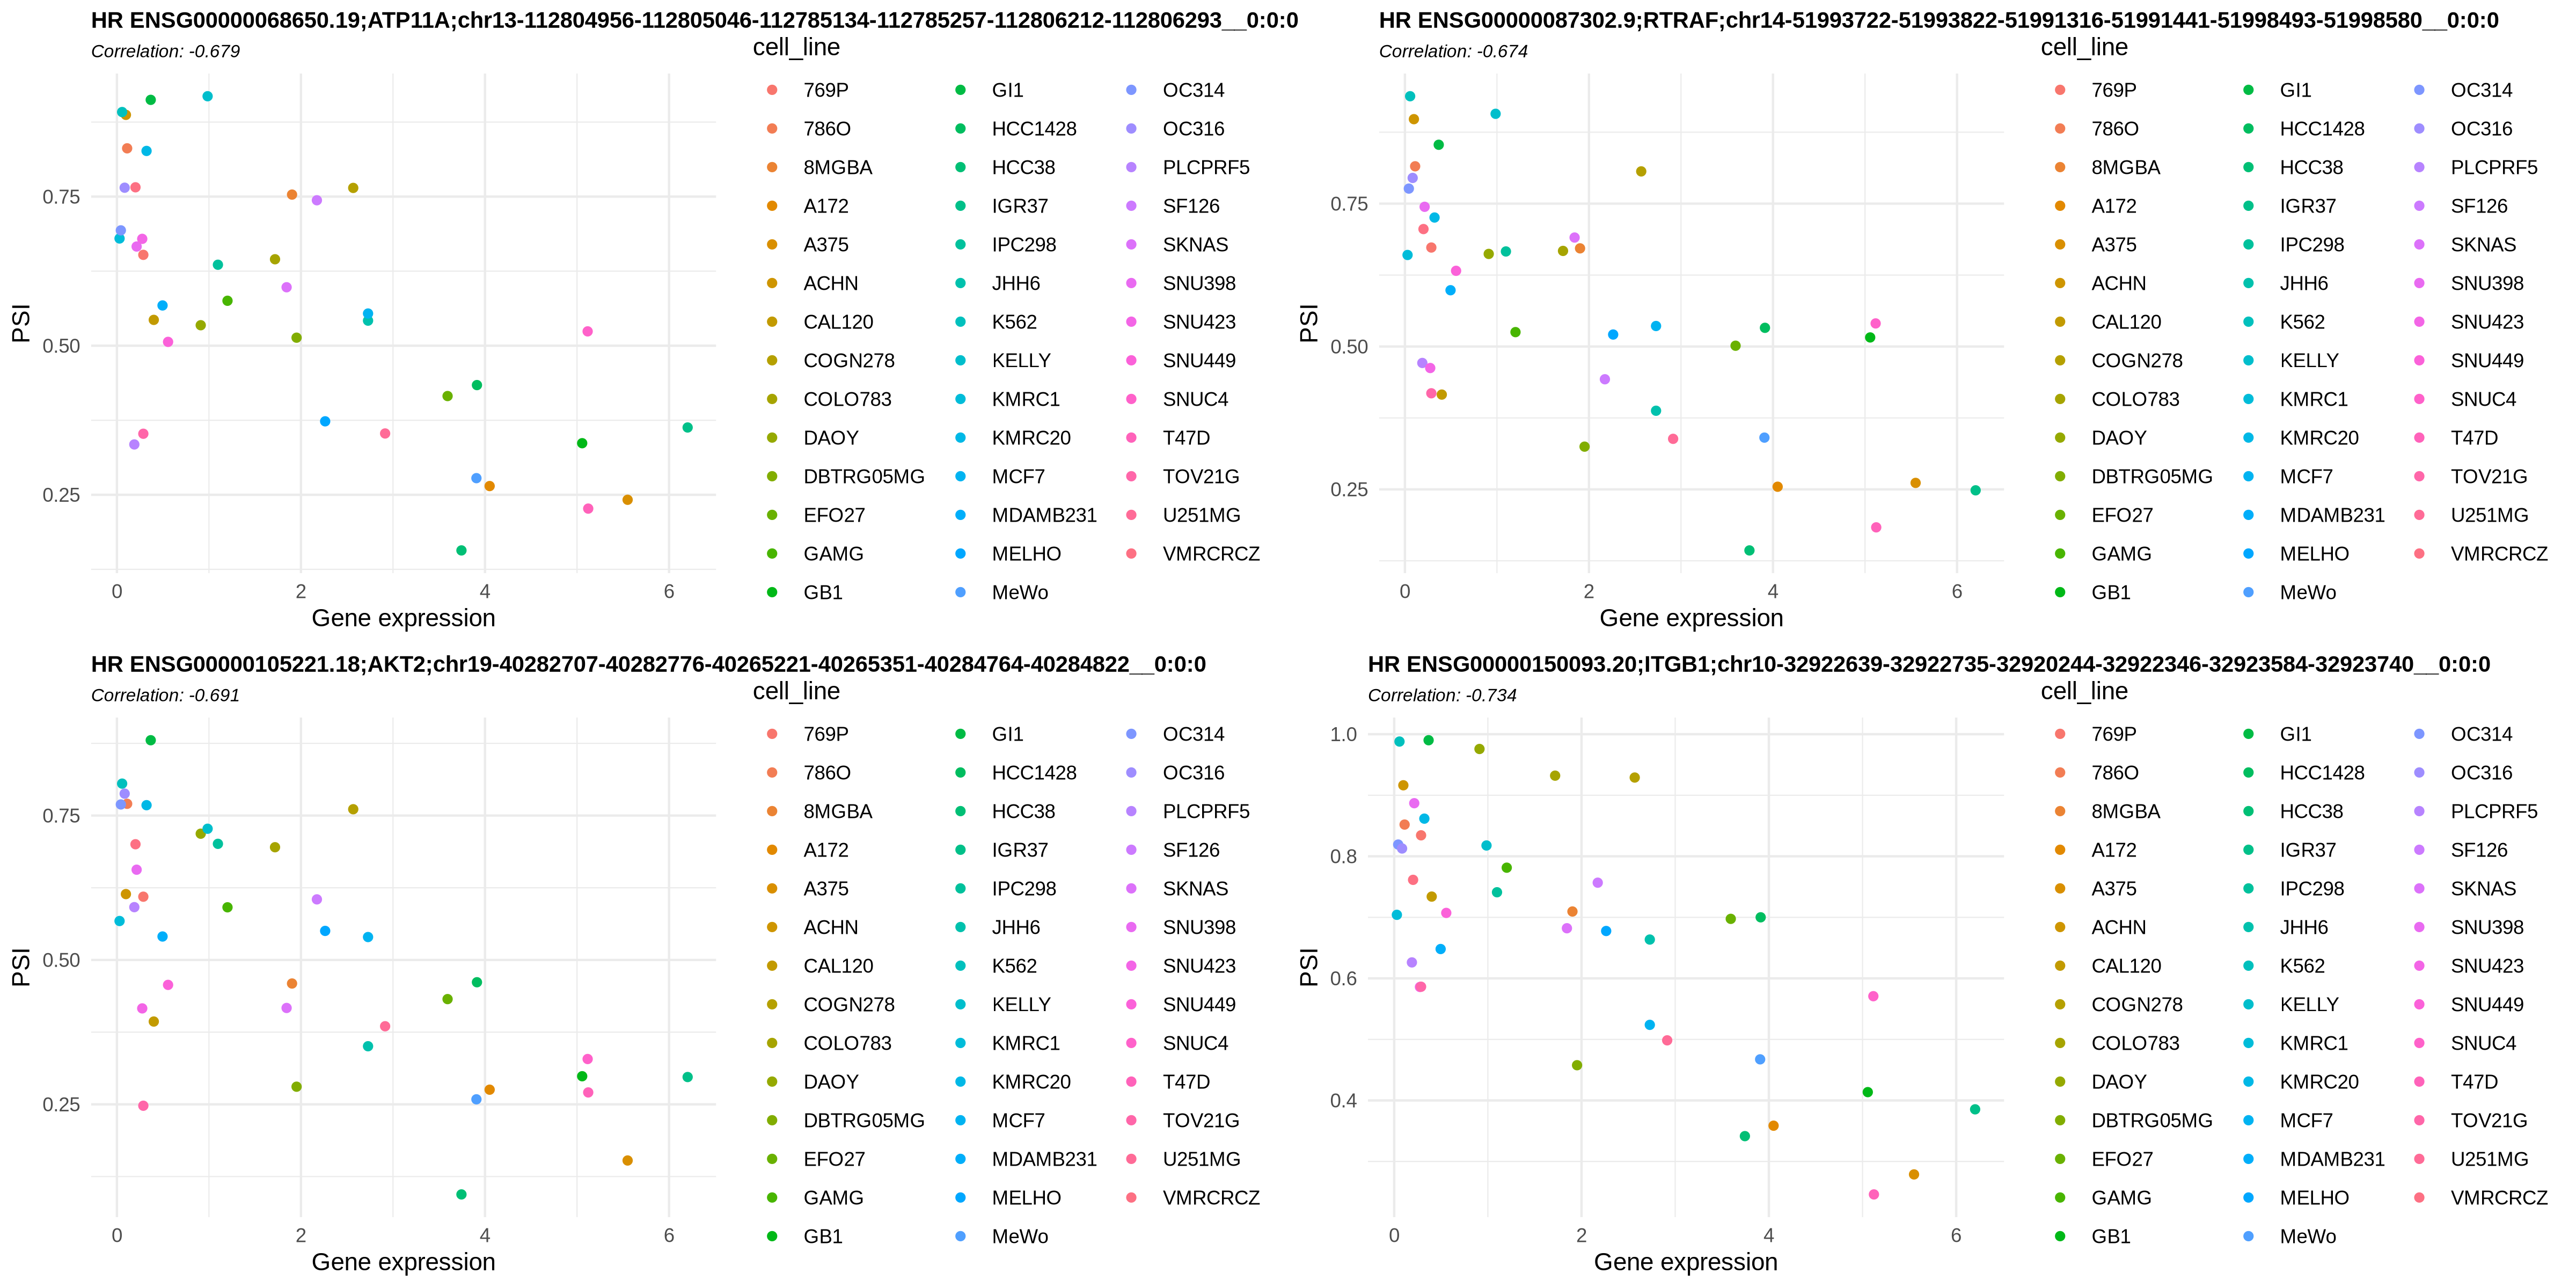

In [26]:
correlation_df_sig <- correlation_df %>% filter(p.val_adj < 0.05)
# plot Correlation histogram.
genes_by_count <- correlation_df_sig %>% 
  group_by(Gene) %>% 
  summarise(n = n()) %>% 
  arrange(desc(n))

# Print all gene names.
print(genes_by_count$Gene)
genes_by_count
# Find all matching sequences for a gene
gene_name <- "HR"
matching_seqs <- correlation_df_sig %>% 
  filter(Gene == gene_name) %>% 
  pull(Exon)


# Create a function to plot correlation for a gene and sequence
plot_gene_seq_correlation <- function(gene, seq) {
  gex_values <- gex_mat_aligned[, gene]
  psi_values <- all_samples_mat_aligned[seq, ]
  corr_val <- cor(gex_values, psi_values, use = "pairwise.complete.obs", method = "pearson")
  
  plot_df <- data.frame(
    gex = gex_values, 
    psi = psi_values, 
    cell_line = rownames(gex_mat_aligned)
  )
  
  p <- ggplot(plot_df, aes(x = gex, y = psi, color = cell_line)) +
    geom_point() + 
    theme_minimal() +
    labs(x = "Gene expression", y = "PSI") + 
    ggtitle(paste(gene, seq)) + 
    theme(plot.title = element_text(size = 10, face = "bold"),
          plot.subtitle = element_text(size = 8, face = "italic")) + 
    labs(subtitle = paste("Correlation:", round(corr_val, 3)))
  
  return(p)
}

# Set plot parameters
options(repr.plot.width = 16, repr.plot.height = 8, repr.plot.res = 300)

# Plot all matching sequences
if (length(matching_seqs) > 0) {
  # Take at most 12 plots
  matching_seqs_limited <- matching_seqs[1:min(4, length(matching_seqs))]
  
  plots <- lapply(matching_seqs_limited, function(seq) {
    plot_gene_seq_correlation(gene_name, seq)
  })
  
  # Display plots in a grid if there are multiple
  if (length(plots) > 1) {
    gridExtra::grid.arrange(grobs = plots, ncol = min(2, length(plots)))
  } else if (length(plots) == 1) {
    plots[[1]]
  } else {
    cat("No matching sequences found for gene:", gene_name)
  }
} else {
  cat("No matching sequences found for gene:", gene_name)
}


In [1]:
# Write gene list to a csv file. 
write_csv(genes_by_count, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/all_transcriptome_genes_by_count.csv")
library(ClusterProfiler)
library(org.Hs.eg.db)

# Convert gene names to ENTREZ IDs
entrez_ids <- mapIds(org.Hs.eg.db, keys = genes_by_count$Gene, column = "ENTREZID", keytype = "SYMBOL", multiVals = "first")

# Create a data frame with gene names and ENTREZ IDs
gene_df <- data.frame(
  gene = genes_by_count$Gene,
  entrez_id = entrez_ids
)

# Run gsea. 
gsea_res <- gseGO(geneList = gene_df$entrez_id,
                  ont = "BP",
                  keyType = "ENTREZID",
                  minGSSize = 10,
                  maxGSSize = 500,
                  pvalueCutoff = 0.05,
                  verbose = FALSE)




ERROR: Error in write_csv(genes_by_count, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/all_transcriptome_genes_by_count.csv"): could not find function "write_csv"
